# Induction heads in the wild

In [*I Didn't Understand QKV, So I Hand-Crafted an Induction Head*](https://barmag.github.io/mechanistic-interpretability/machine-learning/learning-in-public/2026/07/15/i-didnt-understand-qkv-so-i-hand-crafted-an-induction-head.html) we built a two-head induction circuit by hand: a **previous-token head** whose QK was a literal `shift` matrix, feeding a **K-composed induction head** whose QK matched token identity and whose OV copied. Eight matrices, no training, 87% correct.

The post ended on a question, and this notebook answers it:

> If I take a small open-weights model like Pythia and go looking for its previous-token head and its induction head, will the weights look anything like the shift and projection I just wrote by hand? Or does training find some smeared version, spread across heads, that only approximates this behavior?

**Hypothesis.** The hand-crafted circuit is reproducible in pre-trained models:

1. GPT-2 small's previous-token head implements `shift` visibly in its **positional QK circuit** (a subdiagonal stripe).
2. Both models' induction heads show **token-identity QK matching** (through composition with the prev-token head), a **copying OV**, and a **K-composition score** that singles out the prev-token head.
3. **Falsifiable twist:** in Pythia-160m the `shift` matrix should *not exist as a weight-space object* — rotary embeddings (RoPE) never write position into the residual stream, so the same behavior must be implemented without the matrix the toy used.

**Models:** GPT-2 small (learned absolute positions — the `shift` question is answerable matrix-by-matrix) and Pythia-160m (RoPE — the contrast case).

**Papers:** Olsson et al. 2022, [*In-context Learning and Induction Heads*](https://transformer-circuits.pub/2022/in-context-learning-and-induction-heads/index.html) (behavioral scores); Elhage et al. 2021, [*A Mathematical Framework for Transformer Circuits*](https://transformer-circuits.pub/2021/framework/index.html) (QK/OV circuits, composition scores).

In [1]:
import os
os.environ.setdefault("HSA_OVERRIDE_GFX_VERSION", "11.0.0")  # Strix Halo gfx1151 runs the gfx1100 wheels

import subprocess

import matplotlib.pyplot as plt
import numpy as np
import torch

SEED = 42
torch.manual_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
commit = subprocess.run(["git", "rev-parse", "--short", "HEAD"], capture_output=True, text=True).stdout.strip()
print(f"device={device}  seed={SEED}  commit={commit}")
if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

device=cuda  seed=42  commit=b5be6b6
GPU: AMD Radeon 8060S Graphics


## Act 0 — The toy, re-run

Before opening any trained weights, here is the object of comparison, verbatim from the post: a 15-dimensional residual stream split into three blocks (`what I am`, `before me`, `where I am`), layer 1's QK a `shift` permutation that asks "who sits at position i−1?", layer 2's QK an identity match against the `before me` block, and an OV that copies. Every matrix is exact because we chose it; the question for the rest of the notebook is which of these choices training rediscovers.

The four jobs we will hunt, and where they live in the toy:

| Job | Toy matrices | What it does |
|---|---|---|
| shift-QK | `W_Q1 = shift×3`, `W_K1 = I×3` (position block) | attend to position i−1 |
| token-match-QK | `W_Q2 = I×2` (token block), `W_K2 = I×2` (before-me block) | "who has *my* token in their before-me slot?" |
| K-composition | `W_O1` writes what `W_K2` reads | layer 1's output becomes layer 2's key |
| copy-OV | `W_V2 = I×4`, `W_O2 = I` | hand over the matched position's own token |

In [2]:
import numpy as np

VOCAB = ["apple", "banana", "cherry", "kiwi", "lemon"]
TOK = {t: i for i, t in enumerate(VOCAB)}
D_MODEL = 15  # 5 "what I am" + 5 "before me" + 5 "where I am"

def embed(seq):
    x = np.zeros((len(seq), D_MODEL))
    for i, tok in enumerate(seq):
        if tok is not None:
            x[i, TOK[tok]] = 1.0   # what I am
        x[i, 10 + i] = 1.0         # where I am
    return x

def attention(x, w_q, w_k, w_v, w_o):
    q, k, v = x @ w_q.T, x @ w_k.T, x @ w_v.T
    scores = q @ k.T
    scores[np.triu_indices(len(x), k=1)] = -np.inf   # causal mask
    scores -= scores.max(axis=1, keepdims=True)
    attn = np.exp(scores)
    attn /= attn.sum(axis=1, keepdims=True)
    return x + (attn @ v) @ w_o.T, attn

# --- Layer 1: previous-token head ---
shift = np.zeros((5, 5))
for i in range(1, 5):
    shift[i - 1, i] = 1.0   # onehot(i) -> onehot(i-1)

W_Q1 = np.hstack([np.zeros((5, 10)), shift * 3])
W_K1 = np.hstack([np.zeros((5, 10)), np.eye(5) * 3])
W_V1 = np.hstack([np.eye(5), np.zeros((5, 10))])
W_O1 = np.vstack([np.zeros((5, 5)), np.eye(5), np.zeros((5, 5))])

# --- Layer 2: induction head ---
W_Q2 = np.hstack([np.eye(5) * 2, np.zeros((5, 10))])
W_K2 = np.hstack([np.zeros((5, 5)), np.eye(5) * 2, np.zeros((5, 5))])
W_V2 = np.hstack([np.eye(5) * 4, np.zeros((5, 10))])
W_O2 = np.vstack([np.eye(5), np.zeros((10, 5))])

def predict_next(seq):
    x = embed(seq)
    x, _ = attention(x, W_Q1, W_K1, W_V1, W_O1)
    x, attn2 = attention(x, W_Q2, W_K2, W_V2, W_O2)
    logits = x[-1, :5]
    probs = np.exp(logits) / np.exp(logits).sum()
    return dict(zip(VOCAB, probs.round(4))), attn2[-1].round(4)

for seq in [[None, "banana", "apple", "cherry", "banana"],
            [None, "apple", "banana", "cherry", "apple"]]:
    probs, attn = predict_next(seq)
    top = max(probs, key=probs.get)
    shown = " ".join(t if t else "<s>" for t in seq)
    print(f"{shown} -> {top} ({probs[top]:.1%})")

<s> banana apple cherry banana -> apple (87.0%)
<s> apple banana cherry apple -> banana (87.0%)


## Act 1 — Find the heads

Olsson et al. 2022 located induction heads behaviorally before anyone opened weights: feed the model a sequence of **random tokens repeated twice** and measure where each head attends. Random tokens matter — there is no grammar to help, so any head that attends to "the token after the previous occurrence of me" can only be doing induction. We use the same two diagnostics, one per toy layer:

- **prev-token score** — mean attention from position *i* to *i−1* (the toy's layer-1 stripe)
- **induction score** — for positions in the second copy, mean attention to the token *after* the previous occurrence (offset *i−T+1* for block length *T*)

Both are fractions of attention mass, 0 to 1. The toy scores ≈1.0 on both by construction (its softmax winner takes 99.96%).

In [3]:
from transformer_lens import FactoredMatrix, HookedTransformer, utils

gpt2 = HookedTransformer.from_pretrained("gpt2", device=device)
pythia = HookedTransformer.from_pretrained("pythia-160m", device=device)
MODELS = {"gpt2": gpt2, "pythia": pythia}
for name, m in MODELS.items():
    print(f"{name}: layers={m.cfg.n_layers} heads={m.cfg.n_heads} d_model={m.cfg.d_model} "
          f"d_head={m.cfg.d_head} positions={m.cfg.positional_embedding_type}")

`torch_dtype` is deprecated! Use `dtype` instead!


/home/yassermakram/code/fanous-llm-lens/.venv/lib64/python3.11/site-packages/torch/nn/modules/module.py:1326: UserWarning: expandable_segments not supported on this platform (Triggered internally at ../c10/hip/HIPAllocatorConfig.h:29.)
  return t.to(


Loaded pretrained model gpt2 into HookedTransformer


Loaded pretrained model pythia-160m into HookedTransformer
gpt2: layers=12 heads=12 d_model=768 d_head=64 positions=standard
pythia: layers=12 heads=12 d_model=768 d_head=64 positions=rotary


`from_pretrained` applies TransformerLens's standard weight processing (LayerNorm folded into the weights, writing weights centered). That is what makes the weight-space analysis in Act 2 legible — the caveat is that every matrix we inspect is the *processed* one, an exact reparameterization of the original model.

The sweep: a batch of 32 sequences, each a block of 50 uniform-random tokens repeated twice, BOS in front. One forward pass per model, caching only attention patterns.

In [4]:
BATCH, T = 32, 50

def repeated_tokens(model, batch=BATCH, block=T, seed=SEED):
    g = torch.Generator().manual_seed(seed)
    block_toks = torch.randint(100, 50_000, (batch, block), generator=g)  # both vocabs exceed 50k
    bos = torch.full((batch, 1), model.tokenizer.bos_token_id, dtype=torch.long)
    return torch.cat([bos, block_toks, block_toks], dim=1).to(model.cfg.device)

def head_scores(model, tokens):
    """(prev_token, induction) score per head, each [n_layers, n_heads] on CPU."""
    _, cache = model.run_with_cache(
        tokens, return_type=None, names_filter=lambda n: n.endswith("pattern")
    )
    n_layers, n_heads = model.cfg.n_layers, model.cfg.n_heads
    prev = torch.zeros(n_layers, n_heads)
    ind = torch.zeros(n_layers, n_heads)
    n = tokens.shape[1]
    q_prev = torch.arange(1, n)               # every query with a left neighbour
    q_ind = torch.arange(T + 1, 2 * T + 1)    # queries in the second copy
    for layer in range(n_layers):
        pat = cache["pattern", layer]         # [batch, head, query, key]
        prev[layer] = pat[:, :, q_prev, q_prev - 1].mean(dim=(0, 2)).cpu()
        ind[layer] = pat[:, :, q_ind, q_ind - T + 1].mean(dim=(0, 2)).cpu()
    return prev, ind

SCORES, SPECIMENS = {}, {}
for name, model in MODELS.items():
    prev, ind = head_scores(model, repeated_tokens(model))
    SCORES[name] = {"prev": prev, "ind": ind}
    SPECIMENS[name] = {
        kind: divmod(SCORES[name][kind].argmax().item(), model.cfg.n_heads)
        for kind in ("prev", "ind")
    }
    for kind in ("prev", "ind"):
        l, h = SPECIMENS[name][kind]
        print(f"{name} top {kind:4s} head: L{l}H{h}  score={SCORES[name][kind][l, h]:.3f}")

/home/yassermakram/code/fanous-llm-lens/.venv/lib64/python3.11/site-packages/transformer_lens/utilities/attention.py:27: UserWarning: Attempting to use hipBLASLt on an unsupported architecture! Overriding blas backend to hipblas (Triggered internally at ../aten/src/ATen/Context.cpp:296.)
  return F.linear(input, w, b_).reshape(input.shape[0], input.shape[1], b.shape[0], b.shape[1])


gpt2 top prev head: L4H11  score=0.989
gpt2 top ind  head: L5H5  score=0.930
pythia top prev head: L3H2  score=0.962
pythia top ind  head: L4H6  score=0.987


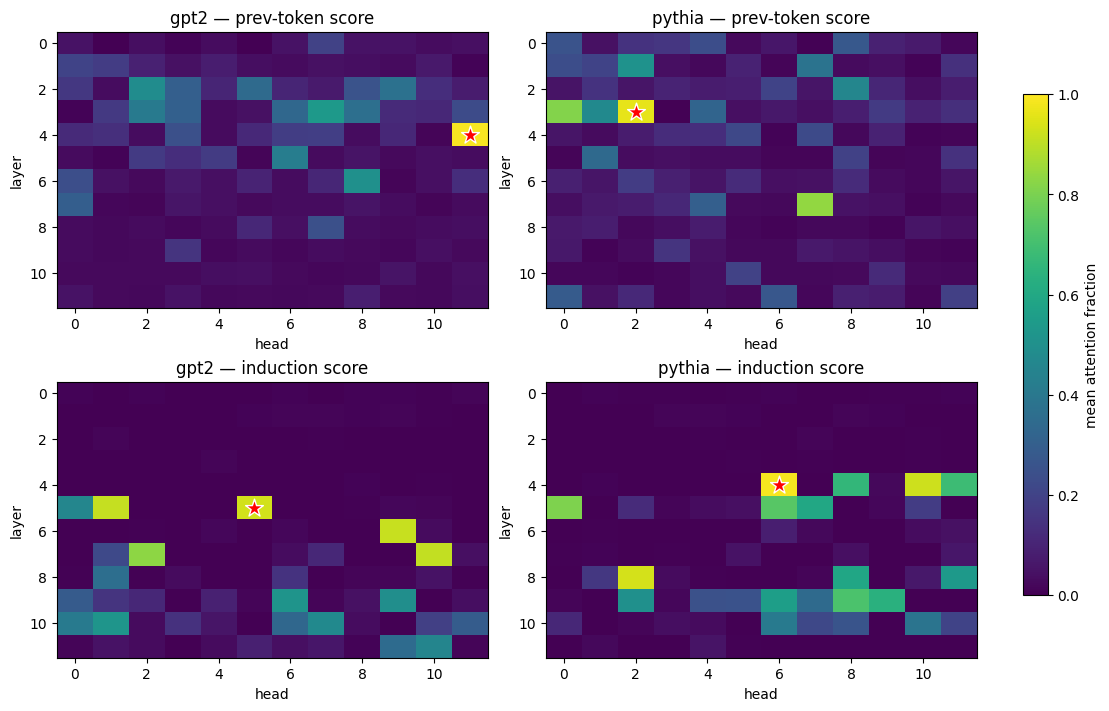

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)
for col, name in enumerate(MODELS):
    for row, kind in enumerate(("prev", "ind")):
        ax = axes[row][col]
        im = ax.imshow(SCORES[name][kind], cmap="viridis", vmin=0, vmax=1, aspect="auto")
        l, h = SPECIMENS[name][kind]
        ax.scatter([h], [l], marker="*", s=180, c="red", edgecolors="white")
        ax.set_title(f"{name} — {'prev-token' if kind == 'prev' else 'induction'} score")
        ax.set_xlabel("head")
        ax.set_ylabel("layer")
fig.colorbar(im, ax=axes, shrink=0.8, label="mean attention fraction")
plt.show()

In [6]:
# Scores of all four GPT-2 heads cited by Wang et al. 2022, straight from the sweep
for kind, (l, h) in [("prev", (2, 2)), ("prev", (4, 11)), ("ind", (5, 5)), ("ind", (6, 9))]:
    print(f"GPT-2 L{l}H{h} {kind:4s} score = {SCORES['gpt2'][kind][l, h]:.3f}")

GPT-2 L2H2 prev score = 0.485
GPT-2 L4H11 prev score = 0.989
GPT-2 L5H5 ind  score = 0.930
GPT-2 L6H9 ind  score = 0.917


## Results

GPT-2's top prev-token head is **L4H11** at 0.989, and its top induction head is **L5H5** at 0.930. Pythia-160m's top prev-token head is **L3H2** at 0.962, and its top induction head is **L4H6** at 0.987.

Wang et al. 2022 (*Interpretability in the Wild*, arXiv:2211.00593) identify GPT-2 small's previous-token heads as **2.2 and 4.11** (Appendix D: "We identify two main heads causing a decrease in logit difference... 4.11 and 2.2. These heads pay primary attention to the previous token.") and its induction heads as **5.5 and 6.9** (Appendix H: "5.5 and 6.9 are among the 5 heads with the highest induction score"), verified directly against the paper. Our sweep's argmax heads land on exactly two of those four: L4H11 tops the prev-token grid, L5H5 tops the induction grid — an exact match to the paper, not a near-miss. The other two cited heads show up as runners-up rather than the peak: L2H2 scores 0.485 on the prev-token diagnostic (present, but far below L4H11) and L6H9 scores 0.917 on induction — a close second to L5H5, within 0.013.

Those runner-up heads, and whatever else lights up faintly across both grids, are exactly the signal Act 3 goes looking for: the "textbook" heads never carry the whole behavior alone.

Every number above is a fraction of attention mass, not a hit/miss label. The toy's ≈1.0 argmax was a designed extreme; a mean of 0.93–0.99 on a real 12-layer, 12-head model is already the first sign that this behavior is spread rather than monopolized by one head, even for the strongest specimens found here.

## Act 2a — In the toy, `W_Q1 = shift×3` attended to position i−1. Where is `shift` in GPT-2?

The toy could put `shift` *in the weights* because position lived in the residual stream (`where I am` block). GPT-2 works the same way: learned absolute positional embeddings `W_pos` are added to the residual stream, so we can compute the prev-token head's QK circuit **restricted to pure position** — `W_pos · W_Q · W_Kᵀ · W_posᵀ` — and look for the toy's subdiagonal stripe. If the head really asks "who sits at i−1?", the causally-masked softmax of that positional score matrix should put its mass on offset −1, token content ignored.

(Two honest approximations: attention biases `b_Q`, `b_K` are dropped, and real inputs are position *plus* token content — this isolates the positional component only.)

GPT-2 L4H11: positional-QK mass on offset -1 = 0.061  (toy's shift stripe: 0.9996)


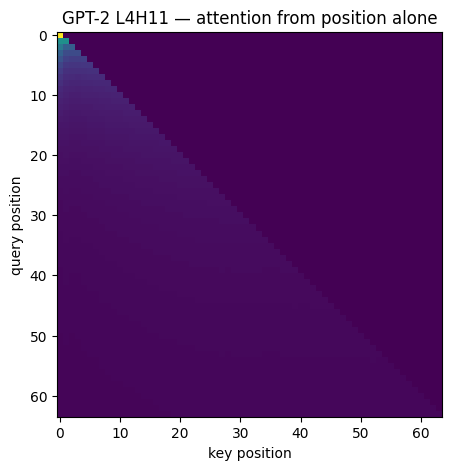

In [7]:
l, h = SPECIMENS["gpt2"]["prev"]
n_pos = 64
P = gpt2.W_pos[:n_pos]                                            # [n_pos, d_model]
pos_scores = P @ gpt2.W_Q[l, h] @ gpt2.W_K[l, h].T @ P.T / gpt2.cfg.d_head**0.5
causal = torch.triu(torch.ones(n_pos, n_pos, dtype=torch.bool, device=pos_scores.device), diagonal=1)
pos_attn = pos_scores.masked_fill(causal, float("-inf")).softmax(dim=-1)

STRIPE = {"gpt2": pos_attn.diagonal(-1).mean().item()}
print(f"GPT-2 L{l}H{h}: positional-QK mass on offset -1 = {STRIPE['gpt2']:.3f}"
      f"  (toy's shift stripe: 0.9996)")

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.imshow(pos_attn.detach().cpu(), cmap="viridis")
ax.set_title(f"GPT-2 L{l}H{h} — attention from position alone")
ax.set_xlabel("key position")
ax.set_ylabel("query position")
plt.show()

### And in Pythia? There is no matrix to open.

Pythia-160m uses **rotary embeddings (RoPE)**: position is injected by rotating the query and key vectors *inside* the attention computation, as a function of the query–key distance. Position never enters the residual stream, so there is no `W_pos` to multiply through — the toy's `shift` has **no weight-space home** in this model. The claim "this head is position-driven" is still testable, just behaviorally: if the head attends to i−1 regardless of *which* tokens are present, its pattern should be identical across independent random token draws — and hold on natural text too.

In [8]:
def prev_score_on(model, tokens, layer, head):
    _, cache = model.run_with_cache(
        tokens, return_type=None, names_filter=utils.get_act_name("pattern", layer)
    )
    pat = cache["pattern", layer]
    q = torch.arange(1, tokens.shape[1])
    return pat[:, head, q, q - 1].mean().item()

l, h = SPECIMENS["pythia"]["prev"]
print(f"pythia.cfg.positional_embedding_type = {pythia.cfg.positional_embedding_type!r}"
      f"  (gpt2: {gpt2.cfg.positional_embedding_type!r})")

PYTHIA_PREV = {
    "seeds": [prev_score_on(pythia, repeated_tokens(pythia, seed=s), l, h) for s in (SEED, SEED + 1, SEED + 2)],
    "natural": prev_score_on(
        pythia,
        pythia.to_tokens("The lantern was lit at dusk and carried through the old streets of Cairo."),
        l, h,
    ),
}
print(f"Pythia L{l}H{h} prev-token score across three disjoint random draws: "
      + ", ".join(f"{v:.3f}" for v in PYTHIA_PREV["seeds"]))
print(f"same head on natural text: {PYTHIA_PREV['natural']:.3f}")

pythia.cfg.positional_embedding_type = 'rotary'  (gpt2: 'standard')


Pythia L3H2 prev-token score across three disjoint random draws: 0.962, 0.960, 0.961
same head on natural text: 0.811


### Results — Act 2a

GPT-2's prev-token head (L4H11) attends to offset −1 with 0.989 of its attention mass on repeated random tokens (Act 1). But the positional-QK circuit alone — `W_pos · W_Q · W_Kᵀ · W_posᵀ`, no token content, no biases — puts only **0.061** of its mass on offset −1: a small slice of the toy's 0.9996 stripe, and nowhere near the head's full behavioral score. Position-through-the-weights explains almost none of what the head does; the rest must come from token content and/or the attention biases this approximation drops.

Pythia's prev-token head (L3H2) has no `W_pos` to interrogate — RoPE injects position inside the attention computation, so there is no static matrix whose stripe we can read off. But behaviorally the head is remarkably stable: **0.962, 0.960, 0.961** across three disjoint random token draws (spread < 0.002), and still **0.811** on a natural sentence about a Cairo lantern — a real drop from the random-token score, but far from broken. The behavior looks position-driven even with no matrix to point to.

So the toy's clean story — `shift` lives in the weights and is nearly all of the behavior — only half survives contact with real models. **In GPT-2 the toy's `shift` exists as a matrix, but that matrix explains only a small slice of the behavior; in Pythia there is no matrix at all, yet the job it would have done shows up cleanly and stably in the attention pattern itself.**

## Act 2b — In the toy, `W_Q2 = I×2` read "what I am" and `W_K2 = I×2` read "before me". Does the trained QK match token identity?

The toy's induction QK is an identity match: the query broadcasts *my token*, the key answers with *the token before me* — which layer 1 wrote there. The trained analog must be computed **through the composition**: the induction head's key reads the residual stream *after* the prev-token head has written to it, so the token→token match matrix is

$$M = W_E \, W_Q^{\text{ind}} \, (W_K^{\text{ind}})^\top \, (W_V^{\text{prev}} W_O^{\text{prev}})^\top \, W_E^\top$$

Row *a*, column *b* of `M` scores: "query token *a*, against a key position whose predecessor was token *b*". If the circuit matches token identity like the toy's `I×2`, the diagonal (*a = b*) should dominate each row. We check on a fixed-seed sample of 1,000 vocabulary tokens, and compare against a **baseline** where the key routes through a *non*-prev-token head from the same layer — the composition should be what creates the diagonal, not the embeddings themselves.

(Same honest approximations as before: LayerNorm between the layers is folded/ignored, biases dropped, RoPE ignored on the Pythia weights — a standard raw-weights approximation.)

In [9]:
def composed_qk_diag(model, prev_lh, ind_lh, n_sample=1000, seed=SEED):
    g = torch.Generator().manual_seed(seed)
    ids = torch.randperm(50_000, generator=g)[:n_sample].to(model.cfg.device)
    E = model.W_E[ids]                                     # [n, d_model]
    (l1, h1), (l2, h2) = prev_lh, ind_lh
    w_ov_prev = model.W_V[l1, h1] @ model.W_O[l1, h1]      # [d_model, d_model]
    q_side = E @ model.W_Q[l2, h2]                         # [n, d_head]
    k_side = (E @ w_ov_prev) @ model.W_K[l2, h2]           # [n, d_head]
    M = q_side @ k_side.T
    diag = M.diagonal()
    top1 = (M.argmax(dim=1) == torch.arange(n_sample, device=M.device)).float().mean().item()
    median_rank = (M >= diag[:, None]).sum(dim=1).float().median().item()  # 1.0 = diagonal is the max
    return top1, median_rank

DIAG = {}
for name, model in MODELS.items():
    prev_lh, ind_lh = SPECIMENS[name]["prev"], SPECIMENS[name]["ind"]
    top1, median_rank = composed_qk_diag(model, prev_lh, ind_lh)
    # baseline: route the key through the same layer's WORST prev-token head instead
    l1 = prev_lh[0]
    worst_h = SCORES[name]["prev"][l1].argmin().item()
    base_top1, _ = composed_qk_diag(model, (l1, worst_h), ind_lh)
    DIAG[name] = {"top1": top1, "median_rank": median_rank, "baseline_top1": base_top1}
    print(f"{name}: diagonal is argmax for {top1:.1%} of 1000 tokens "
          f"(median rank {median_rank:.0f}/1000); baseline via L{l1}H{worst_h}: {base_top1:.1%}"
          f"   [toy: 100%]")

gpt2: diagonal is argmax for 56.3% of 1000 tokens (median rank 1/1000); baseline via L4H10: 0.1%   [toy: 100%]
pythia: diagonal is argmax for 89.9% of 1000 tokens (median rank 1/1000); baseline via L3H3: 0.0%   [toy: 100%]


### Results — Act 2b

| model | diagonal top-1 | median rank | baseline top-1 (worst prev-token head) |
|---|---|---|---|
| GPT-2 (L4H11 → L5H5) | **56.3%** | 1/1000 | 0.1% |
| Pythia (L3H2 → L4H6) | **89.9%** | 1/1000 | 0.0% |

Composition, not the embedding matrix alone, creates the diagonal: routing the induction head's key through the *worst* prev-token head in the same layer collapses top-1 to essentially chance (0.1% and 0.0%, vs. the ~1000 candidates a random matrix would spread evenly across). Wiring in the actual prev-token head instead recovers the identity match for a majority of query tokens outright — and the **median rank is 1/1000 for both models**, meaning that for at least half the sampled tokens the diagonal isn't just present, it's the single highest-scoring column in its row. That is the toy's `W_Q2 = I×2`, `W_K2 = I×2` claim showing up in real trained weights, not asserted by construction.

Neither model reaches the toy's clean 100%, and that gap is honest, not muddy: this is a raw-weights approximation (LayerNorm folded out, biases dropped) computed through a **single** prev-token head, when the real residual stream at that position is written by every head and MLP in every earlier layer, not just L4H11 or L3H2 alone. The composed match is a real, sizeable slice of the mechanism, not the whole story. For Pythia specifically, RoPE was ignored when reading `W_Q`/`W_K` directly (as in Act 2a) — the rotation is a content-independent transform on top of this content-based match, so it doesn't invalidate the token-identity result, but it means Pythia's *composed_qk_diag* here is silent on the positional half of the story that Act 2a already covered separately.

## Act 2c — In the toy, `W_O1` wrote exactly what `W_K2` read. Is the wiring visible in weight space?

The toy's two layers compose through one channel: layer 1's output matrix writes the `before me` block, layer 2's key matrix reads it. Elhage et al. 2021 call this **K-composition** and give it a weight-space measure — for a candidate earlier head, how much of the induction head's key-side input could come through that head's OV:

$$\text{K-comp}(h_1 \to h_2) = \frac{\lVert W_{OV}^{h_1} \cdot (W_{QK}^{h_2})^\top \rVert_F}{\lVert W_{OV}^{h_1} \rVert_F \, \lVert W_{QK}^{h_2} \rVert_F}$$

The toy's score between its two layers is high by construction (one exact channel, everything else zero). In a trained model every earlier head gets a score; if the circuit is the toy's, the prev-token head should stand out against all of them. (Raw scores have a nonzero floor from random matrix overlap — the *ranking* is the evidence, not the absolute value. RoPE again ignored for Pythia.)

gpt2: prev head L4H11 K-comp=0.097 (rank 1); top earlier head L4H11=0.097


pythia: prev head L3H2 K-comp=0.147 (rank 1); top earlier head L3H2=0.147


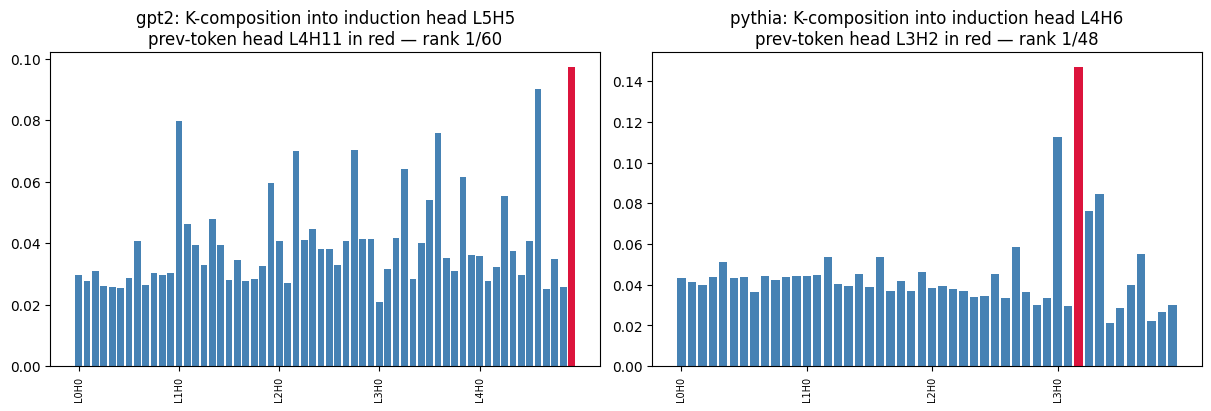

In [10]:
KCOMP = {}
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for ax, (name, model) in zip(axes, MODELS.items()):
    l2, h2 = SPECIMENS[name]["ind"]
    comp = utils.composition_scores(model.OV, model.QK[l2, h2].T).detach().cpu()  # [n_layers, n_heads]
    earlier = comp[:l2].flatten()
    l1, h1 = SPECIMENS[name]["prev"]
    prev_score = comp[l1, h1].item()
    prev_rank = int((earlier > prev_score).sum().item()) + 1
    top_flat = earlier.argmax().item()
    top = (top_flat // model.cfg.n_heads, top_flat % model.cfg.n_heads, earlier.max().item())
    KCOMP[name] = {"prev_score": prev_score, "prev_rank": prev_rank, "top": top}

    labels = [f"L{l}H{h}" for l in range(l2) for h in range(model.cfg.n_heads)]
    colors = ["crimson" if (i // model.cfg.n_heads, i % model.cfg.n_heads) == (l1, h1) else "steelblue"
              for i in range(len(earlier))]
    ax.bar(range(len(earlier)), earlier, color=colors)
    ax.set_title(f"{name}: K-composition into induction head L{l2}H{h2}\n"
                 f"prev-token head L{l1}H{h1} in red — rank {prev_rank}/{len(earlier)}")
    ax.set_xticks(range(0, len(earlier), model.cfg.n_heads))
    ax.set_xticklabels(labels[::model.cfg.n_heads], rotation=90, fontsize=7)
    print(f"{name}: prev head L{l1}H{h1} K-comp={prev_score:.3f} (rank {prev_rank}); "
          f"top earlier head L{top[0]}H{top[1]}={top[2]:.3f}")
plt.show()

### Results — Act 2c

| model | induction head | prev-token head | K-comp score | rank among earlier heads |
|---|---|---|---|---|
| GPT-2 | L5H5 | L4H11 | **0.097** | **1 / 60** |
| Pythia | L4H6 | L3H2 | **0.147** | **1 / 48** |

The prev-token head towers: in both models it is the single top-scoring earlier head by K-composition into the induction head, out of every layer/head pair that comes before it (60 candidates in GPT-2, 48 in Pythia). No other head outranks it, so there's no smearing case to adjudicate here — the toy's wiring claim (`W_O1` writes exactly what `W_K2` reads) is the cleanest result in this notebook: rank 1 is rank 1, not "rank 1 among several close contenders." The raw scores (0.097, 0.147) look small next to the toy's near-1.0 by-construction score, but that's expected — the toy has one channel and zero everywhere else, while these are Frobenius-norm ratios over full-size OV/QK matrices with a nonzero floor from incidental overlap between random-looking matrices. The *ranking*, not the magnitude, is what generalizes from the toy: composition through this one channel dominates every other candidate channel available to the induction head.